# 02 - Feature Analysis
**Credit Score Classification | MLOps Group 8**

This notebook analyzes features AFTER the full preprocessing pipeline:
- Feature importance from Random Forest (baseline)
- Derived feature analysis (10 engineered features)
- Feature variance and low-variance removal
- Pairwise correlation among selected features
- SHAP global feature importance (if model artifact exists)
- Feature group analysis by Credit Score

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

REPO_ROOT   = Path().resolve().parent
DATA_PROC   = REPO_ROOT / 'data' / 'processed'
MODELS_DIR  = REPO_ROOT / 'artifacts' / 'models'
REPORTS_DIR = REPO_ROOT / 'artifacts' / 'reports'
FIGURES_DIR = REPORTS_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

import sys
sys.path.insert(0, str(REPO_ROOT))

print('Repo root:', REPO_ROOT)

Repo root: D:\code\Python\DSEB_ex\MLOps-Group-8


## 1. Load Processed Data

In [2]:
train_path = DATA_PROC / 'train_split.csv'
if not train_path.exists():
    raise FileNotFoundError('Run training_pipeline first to generate processed splits.')

df_train = pd.read_csv(DATA_PROC / 'train_split.csv')
df_valid = pd.read_csv(DATA_PROC / 'valid_split.csv')
df_test  = pd.read_csv(DATA_PROC / 'test_split.csv')

print(f'Train: {df_train.shape}, Valid: {df_valid.shape}, Test: {df_test.shape}')
df_train.head(3)

Train: (69999, 28), Valid: (15001, 28), Test: (15000, 28)


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x3f16,CUS_0x6171,May,NaN,52,584-89-4764,_______,149168.88,NaN,3,5,1,0,NaN,8,7,9.65,0.0000,Good,903.48,43.6101,NaN,No,0.0000,NaN,High_spent_Small_value_payments,1239.9888997857151,Good
1,0x20e75,CUS_0x2596,August,Herbert Lasho,16,174-34-6415,Lawyer,19886.07,1864.1725,8,6,5,2,"Debt Consolidation Loan, and Student Loan",25,11,14.65,5.0000,Standard,1108.32,30.3177,17 Years and 0 Months,Yes,29.6053,50.83236077231178,High_spent_Small_value_payments,365.9795708201834,Poor
2,0x11271,CUS_0x2b99,April,Krista Hughesd,41,208-85-4934,Lawyer,99858.15,8310.5125,3,8,8,4,"Auto Loan, Auto Loan, Payday Loan, and Debt Co...",18,9,9.43,1.0000,Good,1392.72,28.2339,23 Years and 1 Months,No,190.6143,163.1540116403288,High_spent_Small_value_payments,737.2829820302335,Standard


## 2. Apply Preprocessing Pipeline

In [5]:
from src.data.preprocessing import (
    drop_pii_columns, clean_numeric_columns, parse_credit_history_age,
    clean_categorical_columns, cap_outliers, encode_target
)
from src.features.imputers import ImputerPipeline
from src.features.encoders import CategoricalEncoderPipeline
from src.features.build_features import build_features
from src.features.selectors import FeatureSelector

TARGET = 'Credit_Score'

def apply_preprocessing(df, annual_income_cap=None):
    df = drop_pii_columns(df)
    df = clean_numeric_columns(df)
    df = parse_credit_history_age(df)
    df = clean_categorical_columns(df)
    df, cap = cap_outliers(df, annual_income_cap=annual_income_cap)
    return df, cap

train_clean, cap = apply_preprocessing(df_train.copy())
valid_clean, _   = apply_preprocessing(df_valid.copy(), annual_income_cap=cap)

# Encode target
train_clean = encode_target(train_clean)
valid_clean = encode_target(valid_clean)

print(f'After preprocessing -- train: {train_clean.shape}, valid: {valid_clean.shape}')

[preprocessing] Dropped PII: ['ID', 'Customer_ID', 'Name', 'SSN', 'Month'] — remaining cols: 23
[preprocessing] Annual_Income 99th-pct cap = 179,948.84
[preprocessing] Dropped PII: ['ID', 'Customer_ID', 'Name', 'SSN', 'Month'] — remaining cols: 23
After preprocessing -- train: (69999, 23), valid: (15001, 23)


In [6]:
# Impute
imputer = ImputerPipeline()
train_imp = imputer.fit_transform(train_clean)
valid_imp = imputer.transform(valid_clean)

# Encode categoricals
encoder = CategoricalEncoderPipeline()
train_enc = encoder.fit_transform(train_imp)
valid_enc = encoder.transform(valid_imp)

# Feature engineering
train_feat = build_features(train_enc)
valid_feat = build_features(valid_enc)

# Feature selection
selector = FeatureSelector()
X_train = selector.fit_transform(train_feat.drop(columns=[TARGET]))
X_valid = selector.transform(valid_feat.drop(columns=[TARGET]))
y_train = train_feat[TARGET]
y_valid = valid_feat[TARGET]

print(f'X_train: {X_train.shape}, X_valid: {X_valid.shape}')
print(f'Selected features ({X_train.shape[1]}):', list(X_train.columns))

[MedianImputer] Fitted medians:
  Age                                : 34.0000
  Annual_Income                      : 37648.1000
  Monthly_Inhand_Salary              : 3101.0854
  Num_Bank_Accounts                  : 6.0000
  Num_Credit_Card                    : 5.0000
  Interest_Rate                      : 14.0000
  Num_of_Loan                        : 3.0000
  Delay_from_due_date                : 18.0000
  Num_of_Delayed_Payment             : 14.0000
  Changed_Credit_Limit               : 9.3900
  Num_Credit_Inquiries               : 6.0000
  Outstanding_Debt                   : 1161.5100
  Credit_Utilization_Ratio           : 32.2984
  Credit_History_Age                 : 219.0000
  Total_EMI_per_month                : 69.2372
  Amount_invested_monthly            : 129.4506
  Monthly_Balance                    : 336.9412
[ModeImputer] Fitted modes:
  Occupation                         : Lawyer
  Credit_Mix                         : Standard
  Payment_of_Min_Amount              : Yes

## 3. Feature Variance Analysis

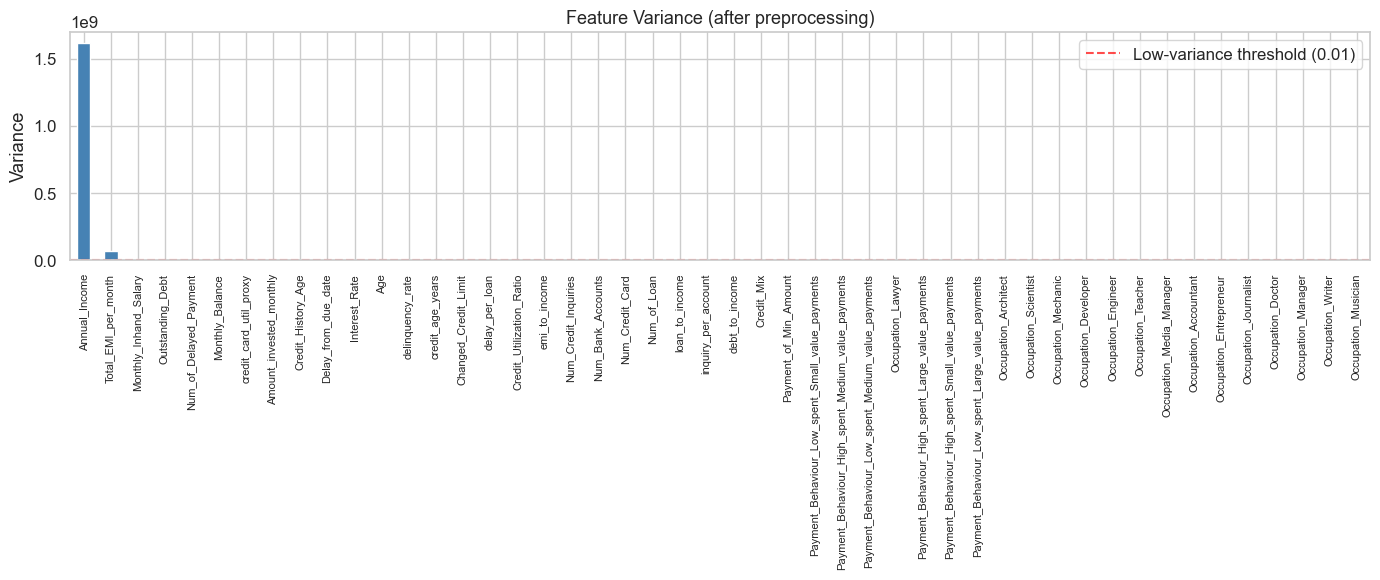

In [7]:
variance = X_train.var().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
variance.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Feature Variance (after preprocessing)', fontsize=13)
ax.set_ylabel('Variance')
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=8)
ax.axhline(0.01, color='red', ls='--', alpha=0.7, label='Low-variance threshold (0.01)')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature_variance.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Baseline Feature Importance (Random Forest)

In [8]:
from sklearn.ensemble import RandomForestClassifier

# Fill any residual NaN
medians = X_train.median()
X_train_f = X_train.fillna(medians)
X_valid_f = X_valid.fillna(medians)

rf = RandomForestClassifier(
    n_estimators=100, max_depth=10, random_state=42,
    n_jobs=-1, class_weight='balanced'
)
rf.fit(X_train_f, y_train)
print(f'RF baseline accuracy on valid: {rf.score(X_valid_f, y_valid):.4f}')

RF baseline accuracy on valid: 0.6796


Saved feature importance to D:\code\Python\DSEB_ex\MLOps-Group-8\artifacts\reports\feature_importance_rf.csv


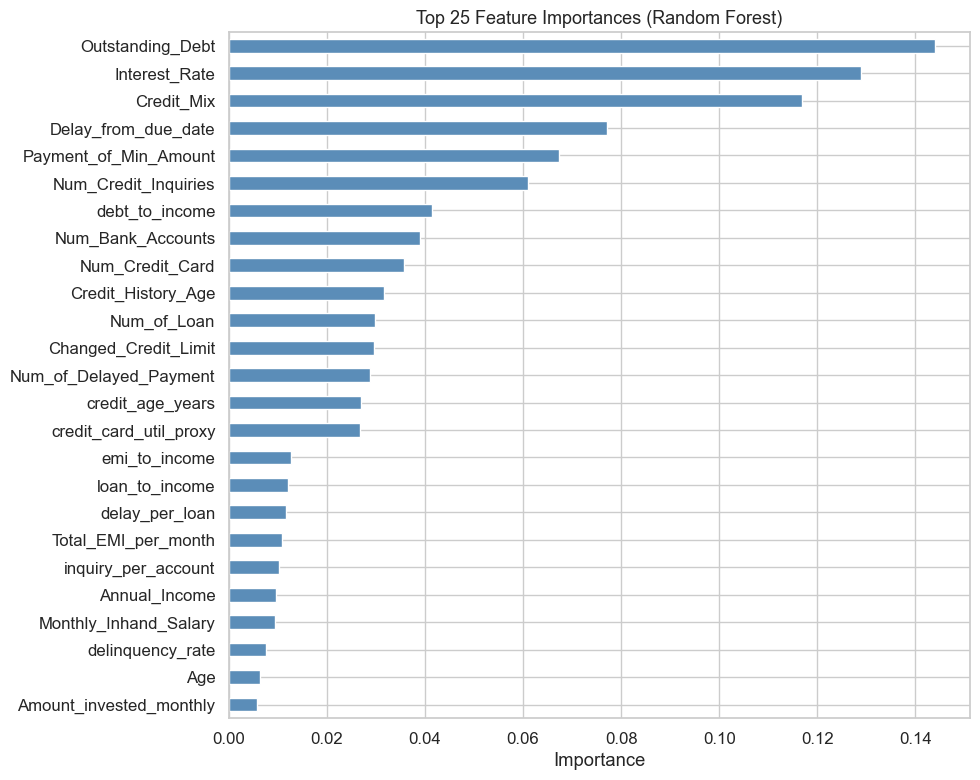

In [9]:
importances = pd.Series(rf.feature_importances_, index=X_train_f.columns)
importances = importances.sort_values(ascending=False)

# Save feature importance CSV
fi_df = importances.reset_index()
fi_df.columns = ['feature', 'importance']
fi_df.to_csv(REPORTS_DIR / 'feature_importance_rf.csv', index=False)
print(f'Saved feature importance to {REPORTS_DIR / "feature_importance_rf.csv"}')

top_n = 25
fig, ax = plt.subplots(figsize=(10, 8))
importances.head(top_n).sort_values().plot(kind='barh', ax=ax, color='#5b8db8')
ax.set_title(f'Top {top_n} Feature Importances (Random Forest)', fontsize=13)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Engineered Feature Analysis

In [10]:
DERIVED_FEATURES = [
    'debt_to_income', 'loan_to_income', 'emi_to_income',
    'savings_rate', 'balance_to_income', 'credit_card_util_proxy',
    'delay_per_loan', 'delinquency_rate', 'inquiry_per_account', 'credit_age_years'
]
derived_present = [f for f in DERIVED_FEATURES if f in X_train_f.columns]
print(f'Derived features in final set: {derived_present}')

if derived_present:
    derived_imp = importances[derived_present].sort_values(ascending=False)
    print('\nDerived feature importances:')
    print(derived_imp.to_string())

Derived features in final set: ['debt_to_income', 'loan_to_income', 'emi_to_income', 'credit_card_util_proxy', 'delay_per_loan', 'delinquency_rate', 'inquiry_per_account', 'credit_age_years']

Derived feature importances:
debt_to_income           0.0414
credit_age_years         0.0270
credit_card_util_proxy   0.0269
emi_to_income            0.0127
loan_to_income           0.0121
delay_per_loan           0.0117
inquiry_per_account      0.0102
delinquency_rate         0.0075


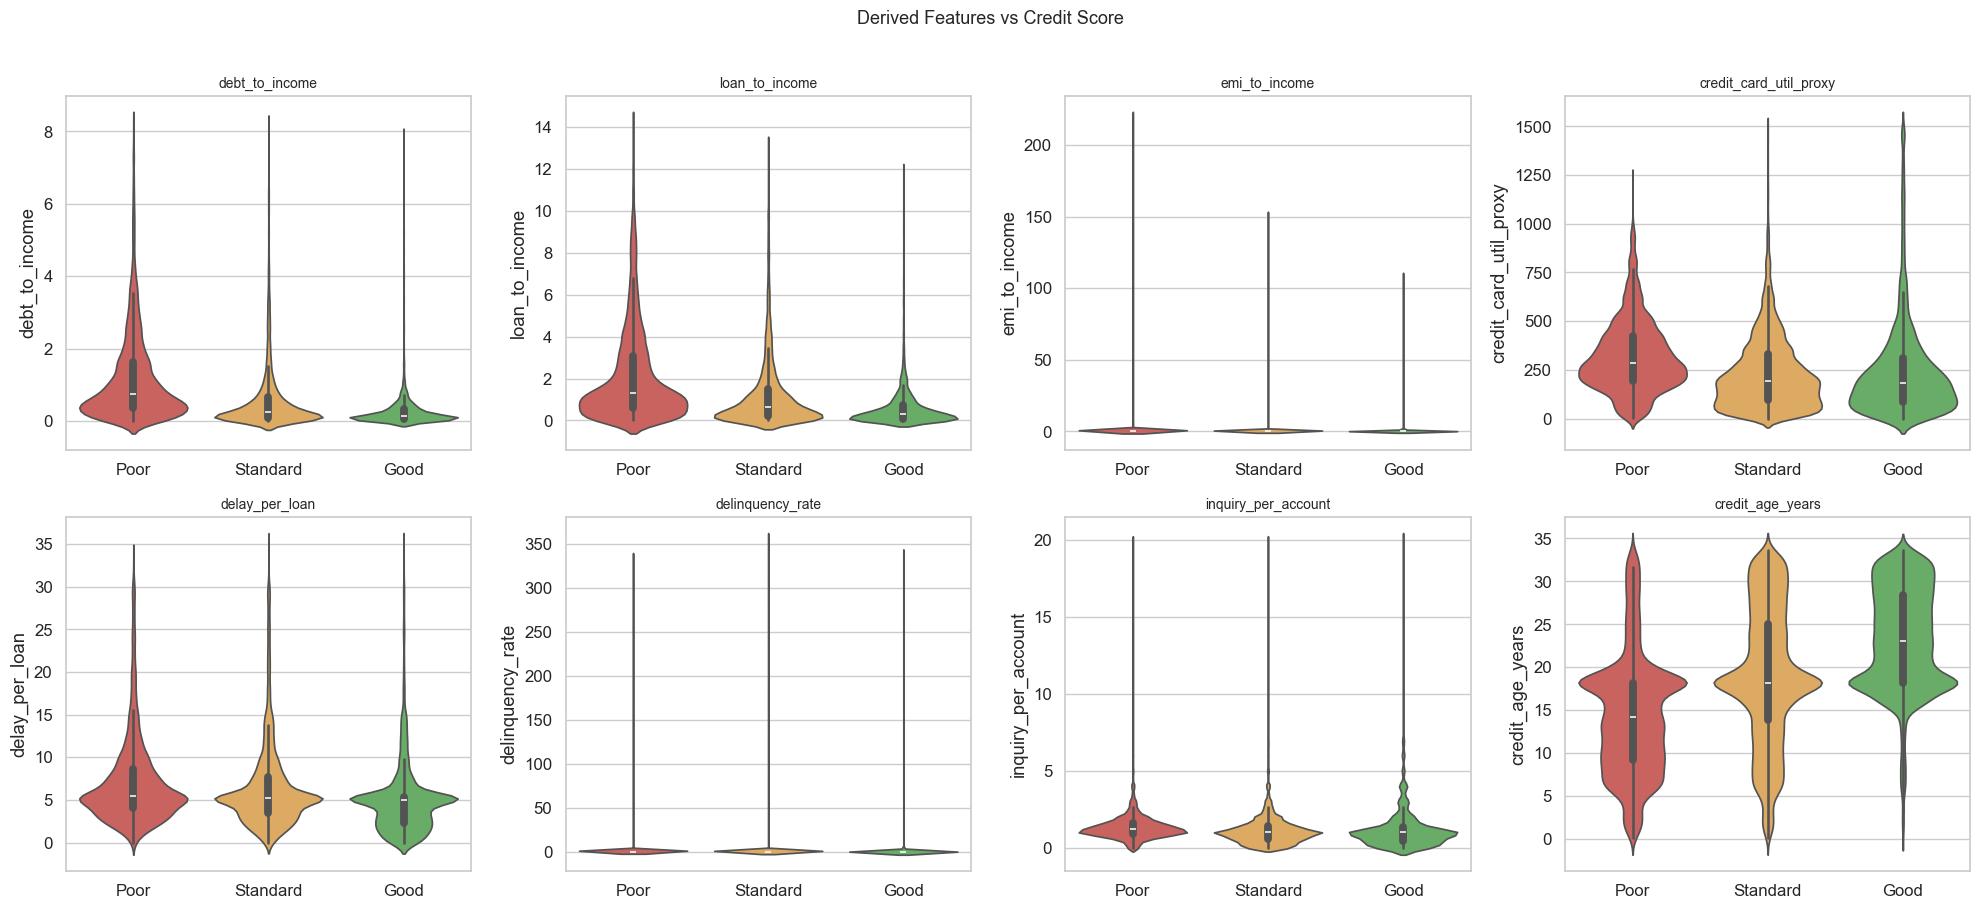

In [11]:
if derived_present:
    fig, axes = plt.subplots(2, (len(derived_present)+1)//2,
                             figsize=(5 * ((len(derived_present)+1)//2), 9))
    axes = axes.flatten()
    order = ['Poor', 'Standard', 'Good']
    palette = {'Poor': '#d9534f', 'Standard': '#f0ad4e', 'Good': '#5cb85c'}
    label_map_inv = {0: 'Poor', 1: 'Standard', 2: 'Good'}

    df_plot = X_train_f[derived_present].copy()
    df_plot['Credit_Score'] = y_train.map(label_map_inv)

    for i, feat in enumerate(derived_present):
        sns.violinplot(
            data=df_plot, x='Credit_Score', y=feat,
            order=order, palette=palette, ax=axes[i], inner='box'
        )
        axes[i].set_title(feat, fontsize=10)
        axes[i].set_xlabel('')

    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Derived Features vs Credit Score', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'derived_features_by_score.png', dpi=150, bbox_inches='tight')
    plt.show()

## 6. Feature Correlation (Post-Selection)

In [12]:
corr = X_train_f.corr()

# Find highly correlated pairs (>0.80)
high_corr_pairs = []
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        val = abs(corr.iloc[i, j])
        if val > 0.80:
            high_corr_pairs.append({
                'feature_a': corr.columns[i],
                'feature_b': corr.columns[j],
                'correlation': round(val, 4)
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('correlation', ascending=False)
print(f'Highly correlated pairs (|r| > 0.80): {len(high_corr_df)}')
if len(high_corr_df) > 0:
    print(high_corr_df.to_string(index=False))

Highly correlated pairs (|r| > 0.80): 3
         feature_a             feature_b  correlation
Credit_History_Age      credit_age_years       1.0000
     Annual_Income Monthly_Inhand_Salary       0.8593
    debt_to_income        loan_to_income       0.8177


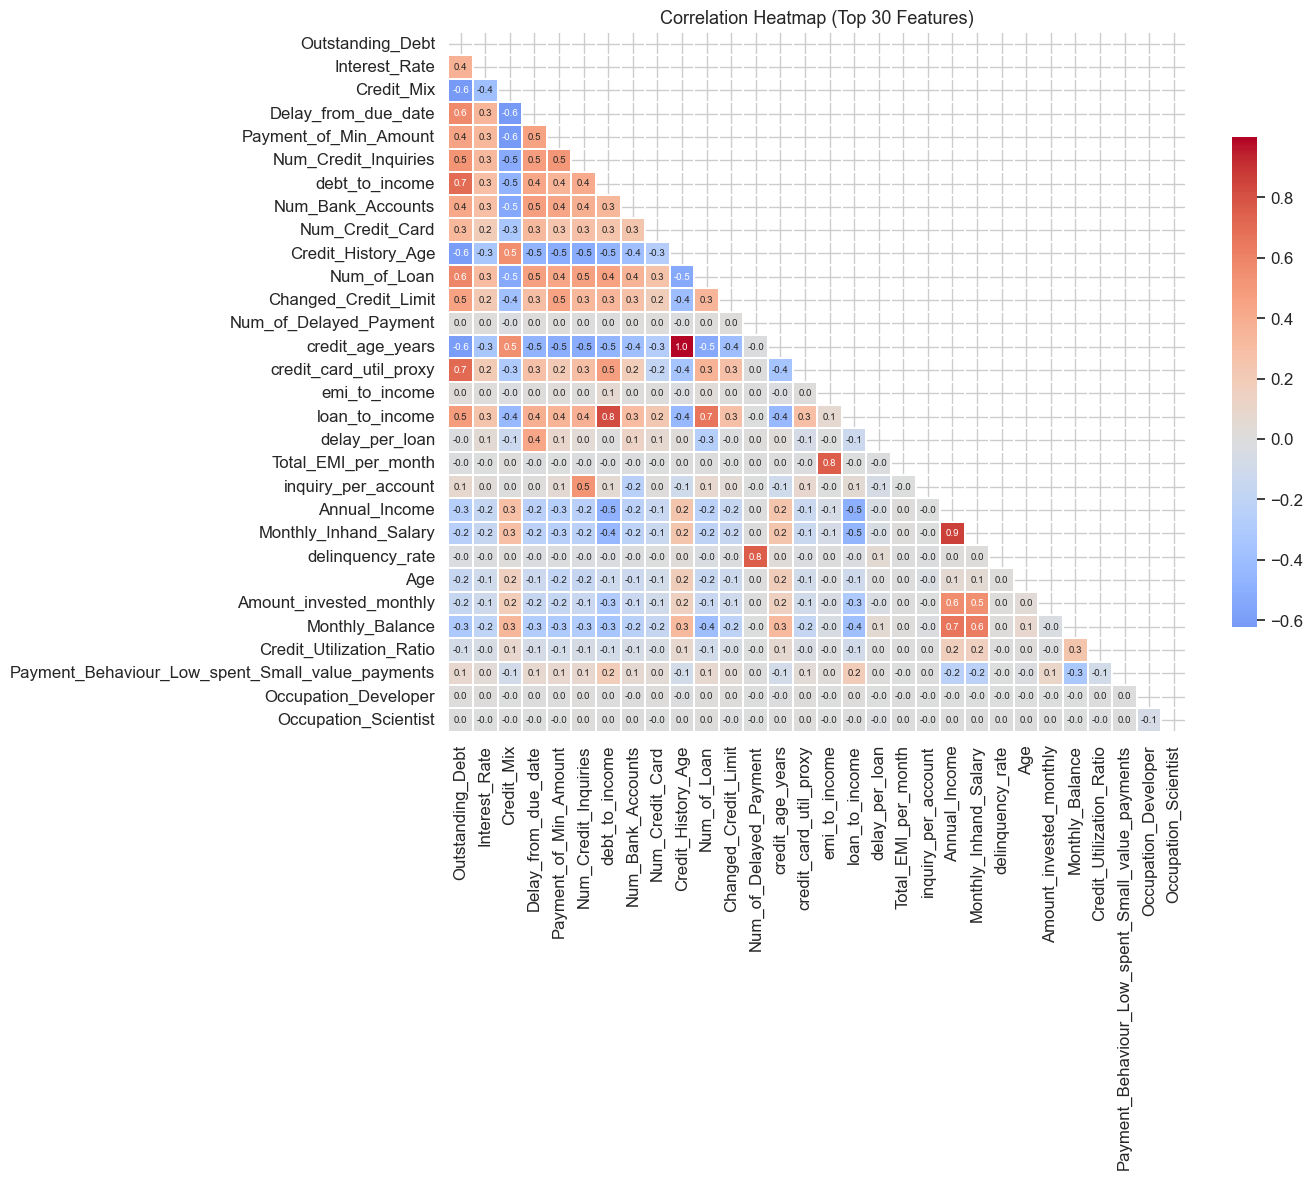

In [13]:
# Clustermap of top 30 features by importance
top30 = importances.head(30).index.tolist()
top30 = [f for f in top30 if f in X_train_f.columns]

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones((len(top30), len(top30)), dtype=bool))
sns.heatmap(
    X_train_f[top30].corr(), mask=mask,
    annot=True, fmt='.1f', cmap='coolwarm', center=0,
    linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.7},
    annot_kws={'size': 7}
)
ax.set_title('Correlation Heatmap (Top 30 Features)', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature_correlation_top30.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. SHAP Feature Importance (if model bundle exists)

In [16]:
# bundle_path = MODELS_DIR / 'final_model_bundle.pkl'
# shap_csv    = REPORTS_DIR / 'shap_feature_importance.csv'

# if shap_csv.exists():
#     shap_df = pd.read_csv(shap_csv)
#     print('Loaded SHAP importances from artifact:')
#     print(shap_df.head(20).to_string(index=False))

#     fig, ax = plt.subplots(figsize=(10, 8))
#     shap_df.head(20).set_index('feature')['mean_abs_shap'].sort_values().plot(
#         kind='barh', ax=ax, color='#e07b54'
#     )
#     ax.set_title('Top 20 SHAP Feature Importances (Final Model)', fontsize=13)
#     ax.set_xlabel('Mean |SHAP|')
#     plt.tight_layout()
#     plt.savefig(FIGURES_DIR / 'shap_importance.png', dpi=150, bbox_inches='tight')
#     plt.show()
# elif bundle_path.exists():
#     try:
#         import shap
#         from src.models.serialize import load_bundle
#         bundle = load_bundle(bundle_path)
#         sample = X_train_f.sample(500, random_state=42)
#         explainer = shap.TreeExplainer(bundle.model)
#         shap_vals = explainer.shap_values(sample)
#         if isinstance(shap_vals, list):
#             mean_shap = np.mean([np.abs(sv).mean(0) for sv in shap_vals], axis=0)
#         else:
#             mean_shap = np.abs(shap_vals).mean(0)
#         shap_imp = pd.Series(mean_shap, index=sample.columns).sort_values(ascending=False)
#         print('SHAP importances computed.')
#         fig, ax = plt.subplots(figsize=(10, 8))
#         shap_imp.head(20).sort_values().plot(kind='barh', ax=ax, color='#e07b54')
#         ax.set_title('Top 20 SHAP Feature Importances', fontsize=13)
#         plt.tight_layout()
#         plt.savefig(FIGURES_DIR / 'shap_importance.png', dpi=150)
#         plt.show()
#     except Exception as e:
#         print(f'SHAP not available or failed: {e}')
# else:
#     print('Model bundle not yet generated -- run the training pipeline first.')

## 8. Feature Group Summary

In [15]:
feature_groups = {
    'Demographic':    ['Age'],
    'Income':         ['Annual_Income', 'Monthly_Inhand_Salary', 'Amount_invested_monthly', 'Monthly_Balance'],
    'Debt':           ['Outstanding_Debt', 'Total_EMI_per_month', 'Num_of_Loan'],
    'Credit Usage':   ['Credit_Utilization_Ratio', 'Changed_Credit_Limit', 'Num_Credit_Inquiries'],
    'Account':        ['Num_Bank_Accounts', 'Num_Credit_Card', 'Credit_History_Age'],
    'Payment':        ['Delay_from_due_date', 'Num_of_Delayed_Payment', 'Interest_Rate'],
    'Derived Ratios': derived_present,
    'Encoded Cat':    [c for c in X_train_f.columns if c.startswith(('ohe_', 'ord_'))]
}

for group, feats in feature_groups.items():
    present = [f for f in feats if f in importances.index]
    if present:
        avg_imp = importances[present].mean()
        print(f'{group:20s} | {len(present):2d} features | avg importance: {avg_imp:.4f}')

Demographic          |  1 features | avg importance: 0.0064
Income               |  4 features | avg importance: 0.0076
Debt                 |  3 features | avg importance: 0.0616
Credit Usage         |  3 features | avg importance: 0.0315
Account              |  3 features | avg importance: 0.0355
Payment              |  3 features | avg importance: 0.0783
Derived Ratios       |  8 features | avg importance: 0.0187
